# F4 — Análisis de resultados SIMCE 2025
**4° Básico · Matemática**

Este cuaderno implementa el análisis final acordado para responder las tres preguntas de investigación:

1. ¿Existen diferencias estadísticamente significativas en los puntajes promedio según ubicación geográfica?
2. ¿Qué regiones, provincias y comunas concentran establecimientos con desempeño inferior a la referencia nacional?
3. ¿Qué establecimientos y territorios pueden identificarse como potenciales focos de priorización?

### Decisiones metodológicas
- La **unidad de análisis inferencial** es el establecimiento.
- Para comparar establecimientos territorialmente se usa el **promedio simple**.
- Para estimar desempeño territorial y construir la referencia de criticidad se usa el **promedio ponderado por estudiantes**.
- El Índice de Criticidad Territorial (ICT) comunal combina **déficit (50%) + concentración (30%) + exposición (20%)**, normalizados mediante percentiles.
- Se selecciona el **P90 del ICT** como criterio de focalización relativa.
- La sensibilidad se comprueba excluyendo comunas bajo P10 del número de establecimientos.

## 1. Configuración, carga y validaciones

In [15]:
from pathlib import Path
from importlib import metadata
import sys, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.oneway import anova_oneway, effectsize_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

candidatos = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
ROOT = next((p for p in candidatos if (p/'src/poo.py').is_file() and (p/'data/raw').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Abra el notebook dentro del repositorio SIMCE con src/ y data/.')
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
from src.analisis_f4 import (validar_entrada, promedio_ponderado, resumen_criticidad,
    calcular_ict, prueba_territorial, REGION, COMUNA)

SEMILLA = 42
CUANTIL_CRITICO = 0.90
np.random.seed(SEMILLA)
OUT = ROOT/'F4/resultados'
OUT.mkdir(parents=True, exist_ok=True)
paquetes = ['numpy','pandas','matplotlib','nbformat','nbclient','ipykernel','ipython']
versiones = {p: metadata.version(p) for p in paquetes}
print('Python:', platform.python_version(), '| Plataforma:', platform.platform())
print('Entorno virtual:', sys.prefix != sys.base_prefix)
display(pd.DataFrame(versiones.items(), columns=['paquete','version']))
pd.set_option('display.max_columns', 14)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

Python: 3.14.7 | Plataforma: Windows-11-10.0.26200-SP0
Entorno virtual: True


,paquete,version
0,numpy,2.5.2
1,pandas,3.0.5
2,matplotlib,3.11.1
3,nbformat,5.11.1
4,nbclient,0.11.0
5,ipykernel,7.3.0
6,ipython,9.17.1


## III. Continuidad y decisiones F2/F3

| Decisión mantenida | Alternativa descartada y razón específica |
|---|---|
| Efectiva: alumnos > 0 y sin observación de puntaje | Reincorporar marca 2 por tener puntaje contradice la advertencia de representatividad |
| No imputar RBD, geografía ni puntaje | Un valor inventado alteraría pertenencia territorial o prioridad de intervención |
| Conservar extremos válidos | Eliminar escuelas grandes o con puntaje extremo borraría precisamente casos relevantes |
| Mantener puntaje y alumnos en sus unidades | Un z-score no responde cuántos alumnos se asocian a cuántos puntos de brecha |
| Geografía embebida y unión validada | Una tabla externa adicional puede desalinear códigos entre ejecuciones |
| Errores detienen el proceso | Eliminar filas inválidas silenciosamente cambiaría el universo y los denominadores |

**Arquitectura y POO.** `Transformador` es una clase abstracta; cinco hijas implementan `transformar`. `PipelineSIMCE` compone esas instancias y las recorre por su interfaz común (polimorfismo). Las propiedades exponen copias o tuplas, evitando que el consumidor altere accidentalmente el registro interno. Se reutiliza esta arquitectura, sin crear otra jerarquía artificial en F4.

Separar `auditoria.py` de `validacion.py` permite conservar evidencia de exclusiones mientras los errores de integridad detienen la ejecución. `configuracion.py` centraliza catálogos para que las clases y las funciones compartan reglas. `poo.py` coordina las transformaciones sin duplicar su lógica. `analisis_f4.py` recibe el producto ya validado: cambiar un gráfico no debe modificar la regla de efectividad.

In [16]:
from src.configuracion import COLUMNAS_SIMCE
from src.carga import cargar_simce, construir_dim_geografia
from src.poo import (PipelineSIMCE, TransformadorTipos, TransformadorTextos,
    TransformadorCategorias, TransformadorGeografia, TransformadorEfectividad)
from src.auditoria import construir_auditoria
from src.transformacion import construir_cobertura_regional
from src.validacion import validar_dataset_final
from src.algoritmo import construir_jerarquia_geografica, validar_geografia_recursiva

raw_path = ROOT/'data/raw/simce4b2025_rbd_final.csv'
f2_path = ROOT/'data/processed/simce4b2025_matematica_efectiva.csv'
df_f2 = pd.read_csv(f2_path, encoding='utf-8-sig', dtype={'no_aplica':'string'}, parse_dates=['fecha_bbdd'])
dim = construir_dim_geografia()
bruto = cargar_simce(raw_path, COLUMNAS_SIMCE)
pipeline = PipelineSIMCE([TransformadorTipos(), TransformadorTextos(),
    TransformadorCategorias(), TransformadorGeografia(dim), TransformadorEfectividad()])
transformado = pipeline.ejecutar(bruto)
reconstruido = pipeline.construir_producto_final(transformado)
auditoria, resumen_auditoria, resumen_marcas = construir_auditoria(transformado)
cobertura = construir_cobertura_regional(transformado)
controles_f3 = validar_dataset_final(reconstruido, transformado, auditoria, cobertura)
cols = sorted(reconstruido.columns)
pd.testing.assert_frame_equal(
    df_f2.sort_values('rbd').reset_index(drop=True)[cols],
    reconstruido.sort_values('rbd').reset_index(drop=True)[cols], check_dtype=False)
assert len(bruto) == len(df_f2) + len(auditoria)
jerarquia = construir_jerarquia_geografica(dim)
assert validar_geografia_recursiva(jerarquia) == []
df = validar_entrada(df_f2)
print(f'Bruto: {len(bruto):,}; efectivos: {len(df):,}; auditados: {len(auditoria):,}.')
print('Igualdad de los 30 campos F2/F3 comprobada; controles:', len(controles_f3))
display(pd.DataFrame(pipeline.registro))
display(cobertura)
comunas_ausentes = dim.loc[~dim.cod_com_rbd.isin(df.cod_com_rbd), ['cod_reg_rbd','region','cod_com_rbd','comuna']]
print('Comunas de la dimensión sin establecimientos efectivos:')
display(comunas_ausentes)

Bruto: 7,143; efectivos: 6,524; auditados: 619.
Igualdad de los 30 campos F2/F3 comprobada; controles: 14


,paso,filas_entrada,filas_salida,columnas_salida
0,TransformadorTipos,7143,7143,20
1,TransformadorTextos,7143,7143,20
2,TransformadorCategorias,7143,7143,24
3,TransformadorGeografia,7143,7143,34
4,TransformadorEfectividad,7143,7143,37


,cod_reg_rbd,region,Zona,Macrozona,Orden,registros_originales,registros_efectivos,registros_no_efectivos,no_efectivos_con_puntaje,alumnos_bruto,alumnos_efectivos,alumnos_no_efectivos
14,15,Arica y Parinacota,Norte,Macrozona Norte,1,81,69,12,1,3023,2946,77
0,1,Tarapacá,Norte,Macrozona Norte,2,109,102,7,0,5295,5290,5
1,2,Antofagasta,Norte,Macrozona Norte,3,136,134,2,0,8307,8305,2
2,3,Atacama,Norte,Macrozona Norte,4,110,102,8,0,4082,4076,6
3,4,Coquimbo,Norte,Macrozona Centro Norte,5,447,372,75,2,10187,10106,81
4,5,Valparaíso,Centro,Macrozona Centro Norte,6,759,740,19,3,21403,21361,42
12,13,Metropolitana de Santiago,Centro,Macrozona Metropolitana,7,1754,1723,31,16,82485,82209,276
5,6,Libertador General Bernardo O'Higgins,Centro,Macrozona Centro Norte,8,445,421,24,5,11885,11798,87
6,7,Maule,Centro,Macrozona Centro Sur,9,558,505,53,6,13615,13507,108
15,16,Ñuble,Centro,Macrozona Centro Sur,10,290,251,39,2,5495,5436,59


Comunas de la dimensión sin establecimientos efectivos:


,cod_reg_rbd,region,cod_com_rbd,comuna
248,12,Magallanes y de la Antártica Chilena,12103,Río Verde
251,12,Magallanes y de la Antártica Chilena,12202,Antártica
256,12,Magallanes y de la Antártica Chilena,12402,Torres del Paine


In [17]:
# Normalización de nombres mínimos usados en F4
ren = {
    "Puntaje promedio": "puntaje_promedio",
    "Exposición": "exposicion",
    "Bajo desempeño": "bajo_desempeno",
}
df = df.rename(columns={k:v for k,v in ren.items() if k in df.columns})

requeridas = [
    "rbd", "region", "provincia", "cod_com_rbd", "comuna",
    "n_alumnos", "puntaje_promedio", "grupo_socioeconomico",
    "ruralidad", "dependencia_4_cat"
]
faltantes = [c for c in requeridas if c not in df.columns]
assert not faltantes, f"Faltan columnas requeridas: {faltantes}"

df["puntaje_promedio"] = pd.to_numeric(df["puntaje_promedio"], errors="coerce")
df["n_alumnos"] = pd.to_numeric(df["n_alumnos"], errors="coerce")

assert df["rbd"].notna().all(), "Hay RBD vacíos."
assert not df["rbd"].duplicated().any(), "Hay RBD duplicados."
assert df["puntaje_promedio"].notna().all(), "Hay puntajes faltantes."
assert df["n_alumnos"].notna().all(), "Hay n_alumnos faltantes."
assert (df["n_alumnos"] > 0).all(), "Hay establecimientos sin estudiantes válidos."

print("✓ Validaciones mínimas superadas.")

✓ Validaciones mínimas superadas.


## 2. Caracterización general y referencias nacionales

In [18]:
n_ee = df["rbd"].nunique()
n_est = int(df["n_alumnos"].sum())
n_reg = df["region"].nunique()
n_prov = df["provincia"].nunique()
n_com = df["cod_com_rbd"].nunique()

promedio_simple_nacional = df["puntaje_promedio"].mean()
promedio_ponderado_nacional = np.average(df["puntaje_promedio"], weights=df["n_alumnos"])

resumen_general = pd.DataFrame({
    "Indicador": [
        "Establecimientos", "Estudiantes", "Regiones", "Provincias", "Comunas",
        "Promedio simple EE", "Promedio nacional ponderado", "Mediana EE", "DE EE"
    ],
    "Valor": [
        n_ee, n_est, n_reg, n_prov, n_com,
        promedio_simple_nacional, promedio_ponderado_nacional,
        df["puntaje_promedio"].median(), df["puntaje_promedio"].std(ddof=1)
    ]
})

# Crear una versión solo para visualización
resumen_mostrar = resumen_general.copy()

indicadores_enteros = [
    "Establecimientos",
    "Estudiantes",
    "Regiones",
    "Provincias",
    "Comunas"
]

resumen_mostrar["Valor"] = resumen_mostrar.apply(
    lambda x: (
        f"{x['Valor']:.0f}"
        if x["Indicador"] in indicadores_enteros
        else f"{x['Valor']:.2f}"
    ),
    axis=1
)

display(resumen_mostrar)
print(f"Referencia ponderada usada para criticidad: {promedio_ponderado_nacional:.2f}")

,Indicador,Valor
0,Establecimientos,6524
1,Estudiantes,212668
2,Regiones,16
3,Provincias,56
4,Comunas,343
5,Promedio simple EE,254.70
6,Promedio nacional ponderado,261.69
7,Mediana EE,254.00
8,DE EE,25.63


Referencia ponderada usada para criticidad: 261.69


## 3. Pregunta 1 — ¿Existen diferencias territoriales en los puntajes?

Antes de identificar territorios críticos, necesitamos responder una pregunta previa: **¿la ubicación geográfica está asociada con diferencias en los puntajes de los establecimientos?**

Para mantener el análisis simple, se realiza una prueba global en tres escalas territoriales: **región, provincia y comuna**. El objetivo de esta etapa **no es seleccionar regiones ni construir un ranking**, sino comprobar si existen diferencias entre territorios que justifiquen avanzar hacia un análisis más detallado.

### Metodología:
- La hipótesis nula plantea que los territorios tienen, en promedio, el mismo desempeño.
- Para saber que método utilizar, en primer lugar se verificará si existe homogeneidad entre las unidades territoriales.
- A continuación, se presenta un análisis descriptivo por territorio.
- Para efectos prácticos, se presentará el análisis detallado a nivel regional.


In [19]:
# Se define función para obtener descriptivos territoriales
def descriptivos_territoriales(datos, geo):
    return (
        datos.groupby(geo)["puntaje_promedio"]
        .agg(N="count", Media="mean", Mediana="median", DE="std",
             P25=lambda x: x.quantile(.25), P75=lambda x: x.quantile(.75))
        .reset_index()
        .sort_values("Media")
    )

desc_region = descriptivos_territoriales(df, "region")
desc_provincia = descriptivos_territoriales(df, "provincia")
desc_comuna = descriptivos_territoriales(df, "comuna")

display(desc_region.round(2))

,region,N,Media,Mediana,DE,P25,P75
6,La Araucanía,668,246.2100,247.0000,27.4500,229.0000,265.0000
13,Tarapacá,102,246.3100,244.0000,23.5300,228.0000,260.0000
9,Los Ríos,251,247.0500,247.0000,27.9600,233.0000,264.0000
2,Atacama,102,248.3400,246.5000,24.4400,236.0000,263.7500
3,Aysén del General Carlos Ibáñez del Campo,52,250.4000,253.0000,25.3800,234.7500,270.0000
14,Valparaíso,740,250.8900,250.0000,22.5600,235.0000,266.0000
8,Los Lagos,494,252.4700,253.0000,26.7600,236.0000,272.0000
5,Coquimbo,372,254.4200,255.0000,26.1600,238.0000,271.0000
10,Magallanes y de la Antártica Chilena,52,254.9600,251.0000,19.7600,238.0000,268.2500
7,Libertador General Bernardo O'Higgins,421,255.3600,255.0000,24.7400,240.0000,272.0000


### Gráfico 1 — Distribución de puntajes por región

El siguiente gráfico presenta la distribución de los puntajes de los establecimientos en cada una de las regiones del país y permite tener una mirada descriptiva del comportamiento de los datos.

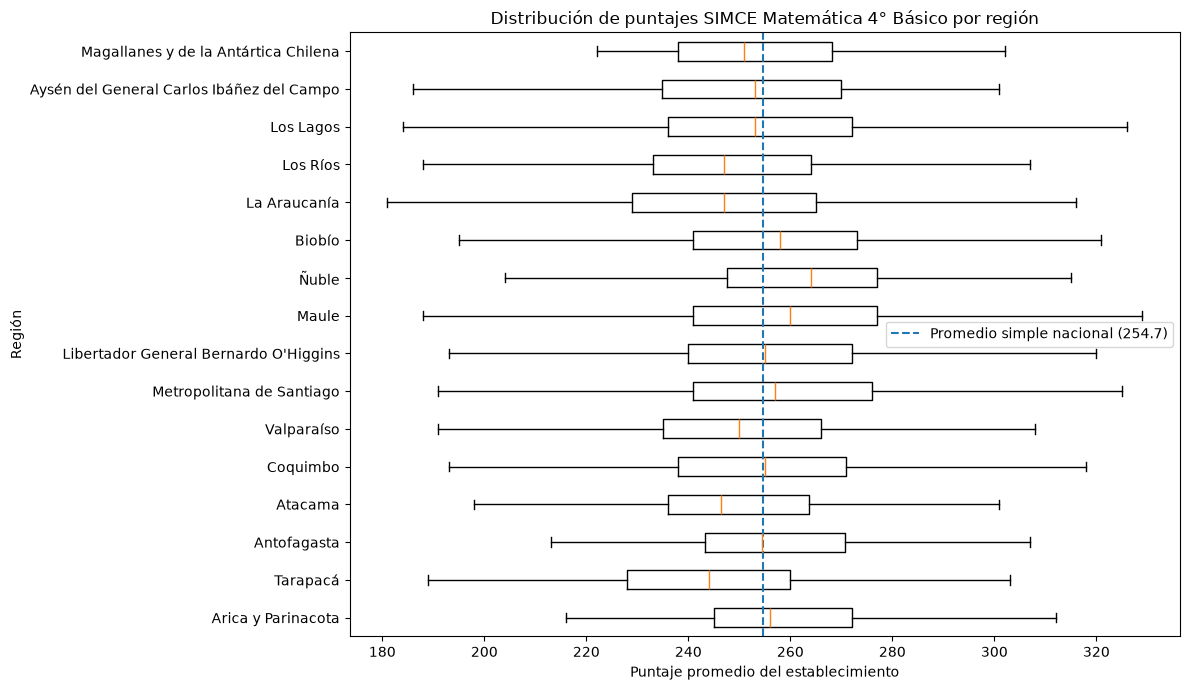

In [20]:
orden_regiones = (
    df[["region", "Orden"]]
    .drop_duplicates()
    .sort_values("Orden")["region"]
    .tolist()
)
datos_box = [df.loc[df["region"].eq(r), "puntaje_promedio"].to_numpy() for r in orden_regiones]

fig, ax = plt.subplots(figsize=(12, 7))
ax.boxplot(datos_box, tick_labels=orden_regiones, orientation="horizontal", showfliers=False)
ax.axvline(promedio_simple_nacional, linestyle="--",
           label=f"Promedio simple nacional ({promedio_simple_nacional:.1f})")
ax.set_title("Distribución de puntajes SIMCE Matemática 4° Básico por región")
ax.set_xlabel("Puntaje promedio del establecimiento")
ax.set_ylabel("Región")
ax.legend()
plt.tight_layout()
plt.show()

### Principales hallazgos descriptivos del Gráfico 1

- Los puntajes **no se distribuyen exactamente de la misma manera en todas las regiones**. 
- Las distribuciones de puntajes **se superponen ampliamente entre regiones**, por lo que no se observa una separación absoluta entre territorios: dentro de todas las regiones existe heterogeneidad entre establecimientos.
- Aun con ese solapamiento, las **medianas y los rangos intercuartílicos no son idénticos**, lo que hace creer en la existencia de diferencias territoriales que posteriormente serán analizadas mediante pruebas estadísticas.
- La línea del promedio simple nacional sirve como referencia para observar que algunas distribuciones regionales se concentran relativamente más hacia puntajes bajos y otras hacia puntajes altos.
- El gráfico debe interpretarse como una **visión general del componente territorial**, no como un ranking de regiones. Su principal aporte es mostrar que el desempeño varía tanto **entre regiones como dentro de ellas**.


In [21]:
def prueba_territorial(datos, geo):
    grupos = [
        g["puntaje_promedio"].dropna().astype(float)
        for _, g in datos.groupby(geo)
        if g["puntaje_promedio"].notna().sum() >= 2
    ]

    # Se verifica homogeneidad de varianzas.
    _, p_levene = stats.levene(*grupos, center="median")

    # Prueba de Levene: homogeneidad de varianzas
    estadistico_levene, p_levene = stats.levene(*grupos, center="median")

    # Se define el resultado de la prueba según el valor p de Levene
    tipo = "equal" if p_levene >= 0.05 else "unequal"

    # Selección de la prueba según el resultado de Levene
    if p_levene >= 0.05:
        # No se rechaza la homogeneidad de varianzas
        nombre_prueba = "ANOVA clásico"
        resultado = stats.f_oneway(*grupos)

    else:
        # Se rechaza la homogeneidad de varianzas
        nombre_prueba = "ANOVA de Welch"
        resultado = anova_oneway(grupos, use_var="unequal", welch_correction=True)

    # Tamaño de efecto global.
    medias = np.array([g.mean() for g in grupos])
    varianzas = np.array([g.var(ddof=1) for g in grupos])
    ns = np.array([len(g) for g in grupos])
    f2 = float(effectsize_oneway(medias, varianzas, ns, use_var=tipo))
    eta2 = f2 / (1 + f2)

    return {
        "Escala territorial": geo.capitalize(),
        "N territorios": len(grupos),
        "Estadístico Levene": estadistico_levene,
        "p Levene": p_levene,
        "Prueba": nombre_prueba,
        "p": float(resultado.pvalue),
        "η² equivalente": eta2
    }

resultados_pruebas = pd.DataFrame([
    prueba_territorial(df, "region"),
    prueba_territorial(df, "provincia"),
    prueba_territorial(df, "comuna"),
])

resultados_pruebas["Conclusión"] = np.where(
    resultados_pruebas["p"] < 0.05,
    "Se observan diferencias territoriales",
    "No se detectan diferencias territoriales"
)

display(resultados_pruebas.round({"Estadístico Levene": 3, "p Levene": 6, "p": 6, "η² equivalente": 3}))

,Escala territorial,N territorios,Estadístico Levene,p Levene,Prueba,p,η² equivalente,Conclusión
0,Region,16,2.7800,0.0003,ANOVA de Welch,0.0000,0.0320,Se observan diferencias territoriales
1,Provincia,55,2.3880,0.0000,ANOVA de Welch,0.0000,0.0480,Se observan diferencias territoriales
2,Comuna,329,1.3660,0.0000,ANOVA de Welch,0.0000,0.2410,Se observan diferencias territoriales


### Lectura de este resultado

- Para comparar homogeneidad entre varianzas se utilizó la prueba de Levene. Esta prueba plantea la hipótesis de que existe igualdad entre las varianzas de los grupos. 
- En todos los escenarios evaluados (región, provincia y comuna), la prueba entregó un `p-value < 0.05`, por lo que podemos rechazar dicha hipótesis e inferir que **al menos un territorio presenta diferencias** 

- Como las dispersiones no son homogéneas, para comprobar nuestra hipótesis inicial relacionada a igualdad de puntajes entre territorios, se utiliza la prueba **ANOVA de Welch**, la cual una versión más robusta ante diferencias de varianza y tamaños de grupo.
- En todos los casos analizados, el `p-value es menor a 0.05`por lo que se rechaza la hipótesis de que todas las unidades territoriales tienen el mismo desempeño y que existe **al menos un territorio con un comportamiento diferente**
- Junto al valor p se presenta un **tamaño de efecto (η² equivalente)**, que ayuda a distinguir entre una diferencia estadísticamente detectable y una diferencia territorial de mayor magnitud. Es decir, que aunque se detectan diferencias estadísticamente significativas en las distintas escalas territoriales, su magnitud no es equivalente. Las diferencias asociadas a la escala regional presentan un tamaño de efecto reducido, mientras que la escala comunal concentra una proporción considerablemente mayor de la variabilidad observada en los puntajes.

Estos resultados permiten responder la primera pregunta de investigación: **sí se observan diferencias estadísticamente significativas en los puntajes de los establecimientos según su ubicación geográfica**.

La comparación regional permite visualizar la existencia de heterogeneidad territorial, pero una región es una unidad demasiado amplia para la focalización. Por ello, después de comprobar estadísticamente las diferencias, el análisis avanza hacia la **escala comunal**, que permite localizar con mayor precisión dónde se concentra el bajo desempeño.

## 4. Pregunta 2 — ¿Dónde se concentra el bajo desempeño?

La sección anterior estableció que **existen diferencias territoriales**. Ahora cambiamos la pregunta desde **“¿hay diferencias?”** hacia **“¿dónde se encuentran los territorios con mayor necesidad relativa?”**

Para ello se adopta la **comuna como unidad principal de focalización**. La elección se justifica por dos razones:

1. El análisis anterior mostró que las diferencias territoriales son más marcadas a esta escala.
2. La comuna entrega un nivel de detalle más útil para focalizar apoyos que una región o provincia completa.

Como referencia se utiliza el **promedio nacional ponderado por el número de estudiantes**. La ponderación permite que el valor nacional represente de mejor manera el desempeño experimentado por el conjunto de estudiantes y no otorgue el mismo peso a establecimientos con matrículas muy distintas.

A partir de esta referencia se identifica cada establecimiento cuyo puntaje está bajo el promedio nacional ponderado. Luego, la información se agrega por comuna para construir tres dimensiones complementarias:

- **Brecha:** cuánto se aleja hacia abajo el puntaje ponderado de la comuna respecto de la referencia nacional.
- **Concentración:** proporción de establecimientos de la comuna que se encuentran bajo la referencia.
- **Exposición:** número de estudiantes que asisten a establecimientos bajo la referencia.

Estas tres dimensiones serán la base del **Índice de Criticidad Territorial (ICT)**.

In [22]:
df["bajo_desempeno_f4"] = (df["puntaje_promedio"] < promedio_ponderado_nacional).astype(int)
df["exposicion_f4"] = np.where(df["bajo_desempeno_f4"].eq(1), df["n_alumnos"], 0)
df["n_x_puntaje"] = df["n_alumnos"] * df["puntaje_promedio"]

def resumen_criticidad(datos, geo_cols):
    g = (
        datos.groupby(geo_cols, dropna=False)
        .agg(
            N_EE=("rbd","count"),
            EE_bajo=("bajo_desempeno_f4","sum"),
            N_estudiantes=("n_alumnos","sum"),
            Suma_n_puntaje=("n_x_puntaje","sum"),
            Exposicion=("exposicion_f4","sum"),
        )
        .reset_index()
    )
    g["Puntaje_ponderado"] = g["Suma_n_puntaje"] / g["N_estudiantes"]
    g["Brecha"] = (promedio_ponderado_nacional - g["Puntaje_ponderado"]).clip(lower=0)
    g["Concentracion"] = g["EE_bajo"] / g["N_EE"]
    return g

res_region_crit = resumen_criticidad(df, ["region"])
res_prov_crit = resumen_criticidad(df, ["region","provincia"])
comunas = resumen_criticidad(df, ["cod_com_rbd","comuna","region"])

display(comunas.head())

,cod_com_rbd,comuna,region,N_EE,EE_bajo,N_estudiantes,Suma_n_puntaje,Exposicion,Puntaje_ponderado,Brecha,Concentracion
0,1101,Iquique,Tarapacá,54,38,2734,"699,070.0000",1759,255.6950,5.9934,0.7037
1,1107,Alto Hospicio,Tarapacá,25,21,2083,"511,457.0000",1709,245.5386,16.1498,0.8400
2,1401,Pozo Almonte,Tarapacá,9,6,279,"69,409.0000",234,248.7778,12.9106,0.6667
3,1402,Camiña,Tarapacá,3,2,18,"5,146.0000",4,285.8889,0.0000,0.6667
4,1403,Colchane,Tarapacá,3,3,21,"4,532.0000",21,215.8095,45.8789,1.0000


## 5. Construcción del Índice de Criticidad Territorial (ICT)

Observar solamente el puntaje promedio podría priorizar comunas con resultados bajos pero con muy pocos establecimientos o estudiantes. Por otra parte, utilizar solo matrícula podría privilegiar comunas grandes aunque su desempeño no sea especialmente bajo.

Para integrar ambas perspectivas se construye un **Índice de Criticidad Territorial (ICT)** con tres componentes transformados a percentiles, de modo que queden expresados en una escala comparable entre 0 y 1:

**ICT = 0,50 × Brecha + 0,30 × Concentración + 0,20 × Exposición**

La **Brecha recibe el mayor peso (50%)** porque el desempeño educativo es el núcleo de la problemática. La **Concentración (30%)** permite distinguir si el bajo desempeño es aislado o extendido dentro de la comuna. Finalmente, la **Exposición (20%)** incorpora la cantidad de estudiantes potencialmente involucrados.

El ICT debe interpretarse como una **herramienta analítica de priorización relativa creada para este proyecto**, no como un indicador oficial del SIMCE.

Dado que los recursos para apoyo son limitados, se selecciona el **10% de comunas con mayor ICT (todas aquellas que estén igual o sobre el percentil 90 "P90")**. Así, el P90 no representa un umbral de “mala calidad”, sino un criterio operativo para identificar un conjunto acotado de territorios con mayor criticidad relativa.

In [23]:
def percentil(serie, significance=3):
    """Replica PERCENTRANK.INC, incluyendo el tratamiento de empates de Excel."""
    s = pd.Series(serie, index=serie.index, dtype=float)
    orden = np.sort(s.dropna().to_numpy())
    n = len(orden)

    # Para valores repetidos Excel utiliza la primera posición del valor.
    unicos, primeros = np.unique(orden, return_index=True)
    percentiles = primeros / (n - 1)

    valores = np.interp(s.to_numpy(), unicos, percentiles)
    return pd.Series(np.round(valores, significance), index=s.index)

comunas["Perc_Brecha"] = percentil(comunas["Brecha"])
comunas["Perc_Concentracion"] = percentil(comunas["Concentracion"])
comunas["Perc_Exposicion"] = percentil(comunas["Exposicion"])

comunas["ICT"] = (
    0.50 * comunas["Perc_Brecha"] +
    0.30 * comunas["Perc_Concentracion"] +
    0.20 * comunas["Perc_Exposicion"]
)
comunas["Perc_ICT"] = percentil(comunas["ICT"])
comunas["P90"] = (comunas["Perc_ICT"] >= .90).astype(int)

corte_p90 = comunas.loc[comunas["P90"].eq(1), "ICT"].min()

print(f"ICT mínimo entre comunas ≥P90: {corte_p90:.4f}")
print(f"Comunas ≥P90: {comunas['P90'].sum()} de {len(comunas)}")
display(comunas.sort_values("ICT", ascending=False).head(20)[
    ["cod_com_rbd","comuna","region","Puntaje_ponderado","Brecha",
     "Concentracion","Exposicion","Perc_Brecha","Perc_Concentracion",
     "Perc_Exposicion","ICT","Perc_ICT"]
].round(4))

ICT mínimo entre comunas ≥P90: 0.7829
Comunas ≥P90: 35 de 343


,cod_com_rbd,comuna,region,Puntaje_ponderado,Brecha,Concentracion,Exposicion,Perc_Brecha,Perc_Concentracion,Perc_Exposicion,ICT,Perc_ICT
17,3102,Caldera,Atacama,239.3514,22.3370,1.0000,259,0.9300,0.8950,0.7110,0.8757,1.0000
8,2102,Mejillones,Antofagasta,240.2418,21.4466,1.0000,244,0.9210,0.8950,0.6930,0.8676,0.9970
311,14106,Mariquina,Los Ríos,241.8782,19.8102,0.9524,304,0.8950,0.8920,0.7370,0.8625,0.9940
72,5705,Putaendo,Valparaíso,236.1081,25.5803,0.9167,181,0.9560,0.8770,0.5880,0.8587,0.9910
1,1107,Alto Hospicio,Tarapacá,245.5386,16.1498,0.8400,1709,0.8390,0.8100,0.9740,0.8573,0.9880
282,13129,San Joaquín,Metropolitana de Santiago,245.2970,16.3914,0.9444,605,0.8450,0.8890,0.8390,0.8570,0.9850
222,10208,Quellón,Los Lagos,241.3848,20.3036,0.8636,346,0.9040,0.8390,0.7510,0.8539,0.9820
19,3201,Chañaral,Atacama,238.2209,23.4675,1.0000,172,0.9390,0.8950,0.5700,0.8520,0.9800
291,13303,Tiltil,Metropolitana de Santiago,240.4559,21.2325,0.9231,223,0.9120,0.8830,0.6490,0.8507,0.9770
47,5201,Isla de Pascua,Valparaíso,235.2857,26.4027,1.0000,133,0.9650,0.8950,0.4770,0.8464,0.9740


### Gráfico 2 — Brecha, exposición y concentración comunal

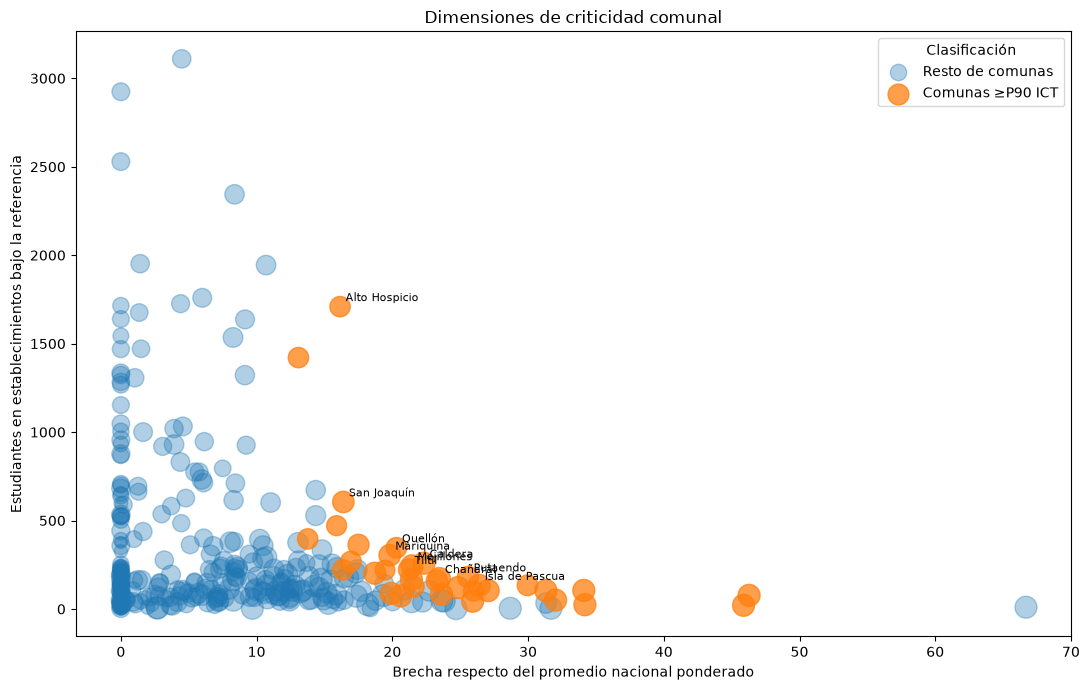

In [24]:
fig, ax = plt.subplots(figsize=(11, 7))
tam = 30 + comunas["Concentracion"] * 220
mask = comunas["P90"].eq(1)

ax.scatter(comunas.loc[~mask,"Brecha"], comunas.loc[~mask,"Exposicion"],
           s=tam.loc[~mask], alpha=.35, label="Resto de comunas")
ax.scatter(comunas.loc[mask,"Brecha"], comunas.loc[mask,"Exposicion"],
           s=tam.loc[mask], alpha=.75, marker="o", label="Comunas ≥P90 ICT")

for _, r in comunas.loc[mask].nlargest(10, "ICT").iterrows():
    ax.annotate(r["comuna"], (r["Brecha"], r["Exposicion"]),
                xytext=(4,4), textcoords="offset points", fontsize=8)

ax.set_title("Dimensiones de criticidad comunal")
ax.set_xlabel("Brecha respecto del promedio nacional ponderado")
ax.set_ylabel("Estudiantes en establecimientos bajo la referencia")
ax.legend(title="Clasificación")
plt.tight_layout()
plt.show()

### Principales hallazgos descriptivos del Gráfico 2

- Las comunas seleccionadas en el **P90 del ICT no presentan un único perfil de criticidad**. Algunas destacan por una brecha de puntaje elevada, otras por una mayor cantidad de estudiantes expuestos y otras por combinar ambas dimensiones.
- El tamaño de los puntos incorpora una tercera dimensión: la **concentración de establecimientos bajo la referencia nacional**. De esta forma, dos comunas con brechas similares pueden presentar niveles de criticidad diferentes si el bajo desempeño está más extendido en una de ellas.
- Entre las comunas de mayor ICT aparecen casos como **Caldera, Mejillones, Mariquina, Putaendo, Alto Hospicio y San Joaquín**, lo que muestra que la selección no se limita a un único territorio del país.
- La dispersión observada confirma la utilidad de combinar las tres dimensiones. Utilizar únicamente el puntaje o únicamente el número de estudiantes habría dejado fuera parte de la información relevante para la focalización.

**Conexión con el análisis siguiente.** El gráfico permite entender visualmente **por qué una comuna puede ser considerada crítica**. El paso siguiente consiste en comprobar si esta selección se mantiene cuando se reduce la influencia potencial de las comunas con pocos establecimientos.

## 6. Análisis de sensibilidad por tamaño comunal

Antes de utilizar el P90 como resultado de focalización, se comprueba que la clasificación no dependa excesivamente de comunas con muy pocos establecimientos.

Como prueba de sensibilidad se excluyen las comunas ubicadas bajo el **percentil 10 de cantidad de establecimientos** y se vuelve a calcular el ICT y el P90. Luego se compara la clasificación original con la nueva.

El objetivo **no es eliminar definitivamente las comunas pequeñas**, sino evaluar la estabilidad del resultado. Una alta permanencia de las comunas originalmente seleccionadas indica que el patrón de criticidad es robusto frente a este cambio metodológico.

In [25]:
# Se conservan las comunas con percentil >= 0,10.
comunas["Perc_RBD"] = percentil(comunas["N_EE"])
sens = comunas.loc[comunas["Perc_RBD"] >= .10].copy()

sens["Perc_Brecha_s"] = percentil(sens["Brecha"])
sens["Perc_Concentracion_s"] = percentil(sens["Concentracion"])
sens["Perc_Exposicion_s"] = percentil(sens["Exposicion"])

sens["ICT_s"] = (
    .50*sens["Perc_Brecha_s"] +
    .30*sens["Perc_Concentracion_s"] +
    .20*sens["Perc_Exposicion_s"]
)
sens["Perc_ICT_s"] = percentil(sens["ICT_s"])
sens["P90_s"] = (sens["Perc_ICT_s"] >= .90).astype(int)

comp = comunas[["cod_com_rbd","comuna","P90"]].merge(
    sens[["cod_com_rbd","ICT_s","Perc_ICT_s","P90_s"]],
    on="cod_com_rbd", how="left"
)

orig_p90 = comp["P90"].eq(1)
elegibles_orig = orig_p90 & comp["P90_s"].notna()
permanecen = elegibles_orig & comp["P90_s"].eq(1)
salen = elegibles_orig & comp["P90_s"].eq(0)
entran = comp["P90"].eq(0) & comp["P90_s"].eq(1)

A = set(comp.loc[elegibles_orig, "cod_com_rbd"])
B = set(comp.loc[comp["P90_s"].eq(1), "cod_com_rbd"])
jaccard = len(A & B) / len(A | B) if (A | B) else np.nan
permanencia = permanecen.sum() / elegibles_orig.sum()

res_sens = pd.DataFrame({
    "Resultado": [
        "Comunas que están igual o sobre el P90 en modelo original",
        "De ellas, cuantas fueron excluidas por estar igual o bajo el P10 de cantidad de EE",
        "Cuantas se mantienen",
        "De las que se mantienen, cuantas quedan igual o sobre el P90 en modelo de sensibilidad",
        "Cuantas dejan de estar igual o sobre el P90",
        "Nuevas comunas que ingresan a P90 en modelo de sensibilidad",
        "Tasa de permanencia",
        "Similitud global (Jaccard)"
    ],
    "Valor": [
        int(orig_p90.sum()),
        int((orig_p90 & comp["P90_s"].isna()).sum()),
        int(elegibles_orig.sum()),
        int(permanecen.sum()),
        int(salen.sum()),
        int(entran.sum()),
        permanencia,
        jaccard
    ]
})
display(res_sens)

print("\nComunas que cambian de clasificación:")
display(comp.loc[salen | entran].merge(
    comunas[["cod_com_rbd","Perc_Brecha","Perc_Concentracion","Perc_Exposicion"]],
    on="cod_com_rbd", how="left"
).sort_values(["P90","comuna"], ascending=[False,True]))

,Resultado,Valor
0,Comunas que están igual o sobre el P90 en mode...,35.0000
1,"De ellas, cuantas fueron excluidas por estar i...",7.0000
2,Cuantas se mantienen,28.0000
3,"De las que se mantienen, cuantas quedan igual ...",27.0000
4,Cuantas dejan de estar igual o sobre el P90,1.0000
5,Nuevas comunas que ingresan a P90 en modelo de...,3.0000
6,Tasa de permanencia,0.9643
7,Similitud global (Jaccard),0.8710



Comunas que cambian de clasificación:


,cod_com_rbd,comuna,P90,ICT_s,Perc_ICT_s,P90_s,Perc_Brecha,Perc_Concentracion,Perc_Exposicion
3,14102,Corral,1,0.7940,0.8990,0.0000,0.9590,0.8950,0.1780
0,3202,Diego de Almagro,0,0.8004,0.9160,1.0000,0.8010,0.8950,0.5640
2,9105,Freire,0,0.7980,0.9130,1.0000,0.8600,0.7570,0.6260
1,6116,Requínoa,0,0.7964,0.9090,1.0000,0.8220,0.7600,0.7080


### Principales hallazgos del análisis

En el modelo original se identificaron 35 comunas en el P90 del ICT. De ellas, 7 quedaron fuera del análisis de sensibilidad por su reducido número de establecimientos, por lo que 28 comunas pudieron ser comparadas directamente entre ambos escenarios. De estas, 27 mantuvieron su clasificación en el P90 y solo una dejó de pertenecer a este grupo, lo que representa una tasa de permanencia de 96,4%. Adicionalmente, tres comunas que no pertenecían originalmente al P90 ingresaron a este grupo al recalcular el índice. La similitud global entre ambas clasificaciones, medida mediante el índice de Jaccard, alcanzó un 87,1%.

Estos resultados muestran que la identificación de las comunas de mayor criticidad es altamente estable frente a la exclusión de territorios con pocos establecimientos. En consecuencia, no se observa evidencia descriptiva suficiente para justificar la eliminación permanente de las comunas pequeñas del análisis principal. Su exclusión implicaría perder información de territorios que, aun teniendo una menor cantidad de establecimientos, pueden presentar niveles relevantes de brecha y concentración del bajo desempeño.

Por esta razón, se opta por conservar la totalidad de las comunas en el modelo definitivo, utilizando el análisis de sensibilidad como una comprobación de robustez y no como un criterio de exclusión. De esta manera, el ICT mantiene una cobertura territorial completa, mientras que la alta permanencia observada permite concluir que la selección de comunas P90 no depende sustancialmente de la presencia de comunas con pocos establecimientos.

## 7. Comunas con mayor criticidad relativa

Una vez comprobada la estabilidad del índice, se ordenan las comunas seleccionadas según su ICT. Para mantener el gráfico legible se muestran las **15 comunas con mayor valor**, aunque el conjunto de focalización corresponde a todas las comunas clasificadas en P90.

### Gráfico 3 — 15 comunas con mayor ICT

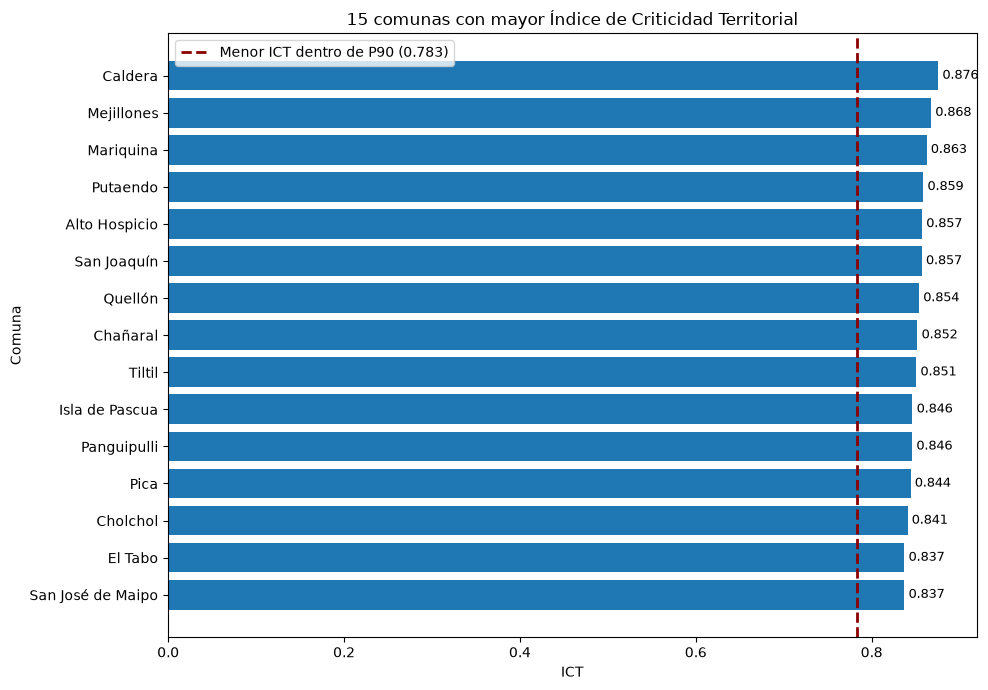

In [26]:
top15 = comunas.loc[comunas["P90"].eq(1)].nlargest(15, "ICT").sort_values("ICT")

fig, ax = plt.subplots(figsize=(10, 7))
barras = ax.barh(top15["comuna"], top15["ICT"])
ax.bar_label(barras, labels=[f"{x:.3f}" for x in top15["ICT"]], padding=3, fontsize=9)
ax.axvline(corte_p90, color="darkred", linestyle="--", linewidth=2,label=f"Menor ICT dentro de P90 ({corte_p90:.3f})")
ax.set_title("15 comunas con mayor Índice de Criticidad Territorial")
ax.set_xlabel("ICT")
ax.set_ylabel("Comuna")
ax.legend()
plt.tight_layout()
plt.show()

### Principales hallazgos descriptivos del Gráfico 3

- El análisis identifica **35 comunas en el P90 del ICT**. El gráfico presenta las 15 con mayor valor para facilitar su lectura, pero la focalización considera el conjunto completo de 35.
- **Caldera presenta el ICT más alto**, seguida por **Mejillones, Mariquina, Putaendo y Alto Hospicio**. Estas posiciones corresponden a la combinación de brecha, concentración y exposición, y no solamente al puntaje promedio de cada comuna.
- Las comunas del gráfico superan el umbral que define el P90, pero existen diferencias de intensidad incluso dentro del grupo seleccionado. Por lo tanto, el P90 funciona como un **criterio de focalización**, mientras que el ICT permite ordenar descriptivamente la criticidad relativa dentro de ese conjunto.
- El análisis de sensibilidad previo mostró una **tasa de permanencia de 96,4%** entre las comunas P90 elegibles para la comparación y una similitud global de **87,1% (Jaccard)**, lo que indica que la selección es relativamente estable frente a la exclusión de comunas pequeñas.

**Conexión con el análisis siguiente.** Una vez identificados los territorios potencialmente prioritarios, el análisis deja de preguntarse **“qué comunas”** y pasa a examinar **“qué establecimientos existen dentro de esas comunas y qué características presentan”**.

## 8. Pregunta 3 — ¿Qué establecimientos se concentran en los territorios priorizados?

Hasta aquí se identificaron las comunas con mayor criticidad relativa. El último paso consiste en **volver desde el territorio hacia los establecimientos** para comprender qué características presentan los establecimientos ubicados en esas comunas.

Se consideran **todos los establecimientos de las comunas P90** y se dividen en dos grupos:

- establecimientos con puntaje bajo la referencia nacional ponderada;
- establecimientos que, aun estando en una comuna P90, no se encuentran bajo dicha referencia.

Esta comparación es importante porque una comuna priorizada **no implica que todos sus establecimientos presenten bajo desempeño**.

Para cada grupo se describen número de establecimientos y estudiantes, puntaje promedio y mediana, composición por grupo socioeconómico, ruralidad, dependencia administrativa y estudiantes promedio por establecimiento.

En esta sección el **puntaje promedio es simple**, porque la unidad que se está caracterizando es el establecimiento. Estas variables se utilizan con un propósito **descriptivo y no causal**.

In [27]:
codigos_p90 = set(comunas.loc[comunas["P90"].eq(1), "cod_com_rbd"])
ee_p90 = df.loc[df["cod_com_rbd"].isin(codigos_p90)].copy()
ee_p90["Grupo"] = np.where(
    ee_p90["bajo_desempeno_f4"].eq(1),
    "Bajo desempeño", "Sin bajo desempeño"
)

def porcentaje_cond(g, condicion):
    return 100 * condicion(g).mean()

filas = []
for grupo, g in ee_p90.groupby("Grupo"):
    gse = g["grupo_socioeconomico"].astype(str).str.strip().str.lower()
    dep = g["dependencia_4_cat"].astype(str).str.strip().str.lower()
    rur = g["ruralidad"].astype(str).str.strip().str.lower()

    filas.append({
        "Grupo": grupo,
        "N establecimientos": len(g),
        "% establecimientos": 100*len(g)/len(ee_p90),
        "N estudiantes": int(g["n_alumnos"].sum()),
        "% estudiantes": 100*g["n_alumnos"].sum()/ee_p90["n_alumnos"].sum(),
        "Puntaje promedio EE": g["puntaje_promedio"].mean(),
        "Mediana": g["puntaje_promedio"].median(),
        "% EE GSE Bajo / Medio Bajo": 100*gse.isin(["bajo","medio bajo"]).mean(),
        "% EE GSE Medio": 100*gse.eq("medio").mean(),
        "% EE GSE Medio Alto / Alto": 100*gse.isin(["medio alto","alto"]).mean(),
        "% EE Rurales": 100*rur.eq("rural").mean(),
        "% EE Municipales / Serv. Local": 100*(
            dep.str.contains("municipal", na=False) |
            dep.str.contains("servicio local", na=False)
        ).mean(),
        "Estudiantes promedio / EE": g["n_alumnos"].mean()
    })

caracterizacion = pd.DataFrame(filas).set_index("Grupo").T
# Orden esperado en presentación
orden_cols = [c for c in ["Bajo desempeño","Sin bajo desempeño"] if c in caracterizacion.columns]
caracterizacion = caracterizacion[orden_cols]
display(caracterizacion.round(2))

Grupo,Bajo desempeño,Sin bajo desempeño
N establecimientos,365.0000,39.0000
% establecimientos,90.3500,9.6500
N estudiantes,"9,320.0000","1,528.0000"
% estudiantes,85.9100,14.0900
Puntaje promedio EE,233.8500,272.6900
Mediana,236.0000,271.0000
% EE GSE Bajo / Medio Bajo,76.4400,58.9700
% EE GSE Medio,19.4500,28.2100
% EE GSE Medio Alto / Alto,4.1100,12.8200
% EE Rurales,46.8500,35.9000


### Gráfico 4 — Caracterización comparativa

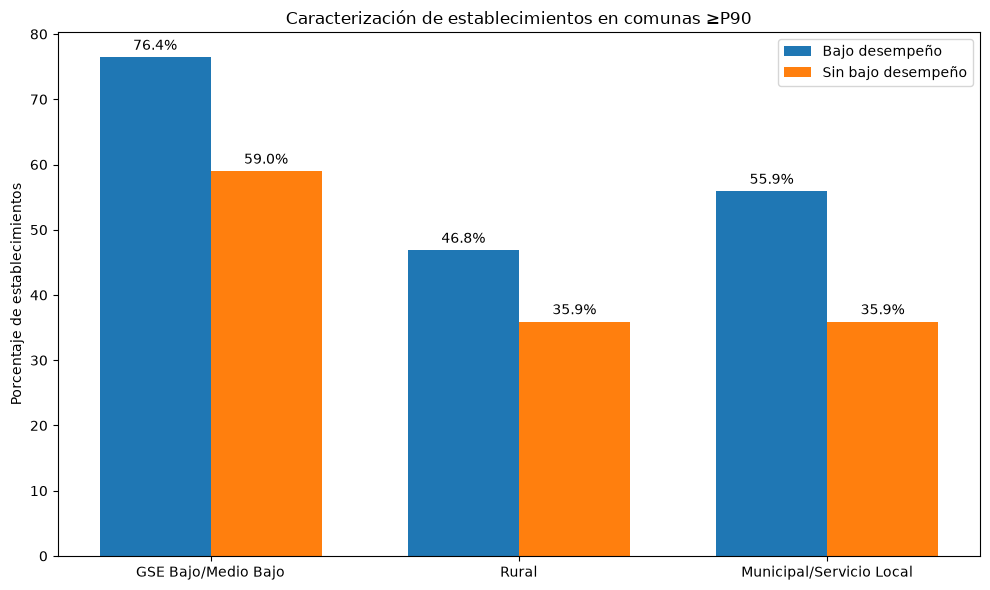

In [28]:
graf_car = pd.DataFrame({
    "Característica": ["GSE Bajo/Medio Bajo", "Rural", "Municipal/Servicio Local"],
    "Bajo desempeño": [
        caracterizacion.loc["% EE GSE Bajo / Medio Bajo","Bajo desempeño"],
        caracterizacion.loc["% EE Rurales","Bajo desempeño"],
        caracterizacion.loc["% EE Municipales / Serv. Local","Bajo desempeño"],
    ],
    "Sin bajo desempeño": [
        caracterizacion.loc["% EE GSE Bajo / Medio Bajo","Sin bajo desempeño"],
        caracterizacion.loc["% EE Rurales","Sin bajo desempeño"],
        caracterizacion.loc["% EE Municipales / Serv. Local","Sin bajo desempeño"],
    ]
})

x = np.arange(len(graf_car))
w = 0.36
fig, ax = plt.subplots(figsize=(10,6))
b1 = ax.bar(x-w/2, graf_car["Bajo desempeño"], width=w, label="Bajo desempeño")
b2 = ax.bar(x+w/2, graf_car["Sin bajo desempeño"], width=w, label="Sin bajo desempeño")
ax.set_xticks(x, graf_car["Característica"])
ax.set_ylabel("Porcentaje de establecimientos")
ax.set_title("Caracterización de establecimientos en comunas ≥P90")
ax.legend()
ax.bar_label(b1, fmt="%.1f%%", padding=3)
ax.bar_label(b2, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

### Principales hallazgos descriptivos del Gráfico 4

- Dentro de las comunas P90, los establecimientos de bajo desempeño son en gran parte de un **GSE Bajo/Medio Bajo (76,4%)**, mientras que para los establecimientos sin bajo desempeño esa proporción disminuye(**59,0%**). Esto equivale a una diferencia aproximada de **17,5 puntos porcentuales**.
- La **ruralidad** también es más frecuente entre los establecimientos de bajo desempeño: **46,8% frente a 35,9%**, una diferencia cercana a **10,9 puntos porcentuales**.
- La mayor diferencia de las tres características representadas se observa en la dependencia administrativa **Municipal/Servicio Local**: Un **55,9% de los establecimientos de bajo desempeño** son de estas dependencias mientras que el **35,9% de los establecimientos sin bajo desempeño** corresponde a establecimientos públicos. Esta diferencia equivalente a aproximadamente **20 puntos porcentuales**.
- Estos patrones complementan la caracterización general: en las comunas P90, **365 de 404 establecimientos (90,35%)** están bajo la referencia nacional y concentran **85,91% de los estudiantes** analizados en esos territorios.
- Los resultados son **descriptivos**. Las diferencias observadas permiten caracterizar los establecimientos asociados al bajo desempeño, pero no demuestran que el GSE, la ruralidad o la dependencia sean causas de los resultados SIMCE.

**Lectura final.** La caracterización muestra que la priorización territorial obtenida mediante el ICT puede complementarse con información sobre los establecimientos que integran esos territorios. De esta forma, el análisis responde no solo **dónde** se concentra la criticidad, sino también **qué características presentan los establecimientos asociados al bajo desempeño dentro de las comunas seleccionadas**.

## 9. Síntesis reproducible de resultados

In [29]:
print("="*76)
print("SÍNTESIS DE RESULTADOS")
print("="*76)

# Caracterización general
print(f"Establecimientos analizados: {n_ee:,}")
print(f"Estudiantes: {n_est:,}")
print(f"Promedio simple nacional EE: {promedio_simple_nacional:.2f}")
print(f"Promedio nacional ponderado: {promedio_ponderado_nacional:.2f}")

# Diferencias territoriales 
print()
print("Diferencias territoriales")

for _, r in resultados_pruebas.iterrows():
    ptxt = "<0,001" if r["p"] < .001 else f"{r['p']:.3f}"
    print(
        f"{r['Escala territorial']}: "
        f"{r['Prueba']} | "
        f"p {ptxt} | "
        f"η² equiv. = {r['η² equivalente']:.3f}"
    )

# Focalización comunal
print()
print("Focalización comunal")
print(f"Comunas ≥P90 ICT: {int(comunas['P90'].sum())}")
print(f"Tasa de permanencia sensibilidad: {permanencia:.1%}")
print(f"Similitud global Jaccard: {jaccard:.1%}")

# Caracterización de establecimientos
if "Bajo desempeño" in caracterizacion.columns:
    print()
    print("Caracterización de establecimientos dentro de comunas ≥P90:")
    print(f"EE bajo desempeño: {int(caracterizacion.loc['N establecimientos','Bajo desempeño'])}")
    print(f"% EE bajo desempeño: {caracterizacion.loc['% establecimientos','Bajo desempeño']:.2f}%")
    print(f"Estudiantes en EE bajo desempeño: {int(caracterizacion.loc['N estudiantes','Bajo desempeño']):,}")
    print(f"% estudiantes: {caracterizacion.loc['% estudiantes','Bajo desempeño']:.2f}%")

SÍNTESIS DE RESULTADOS
Establecimientos analizados: 6,524
Estudiantes: 212,668
Promedio simple nacional EE: 254.70
Promedio nacional ponderado: 261.69

Diferencias territoriales
Region: ANOVA de Welch | p <0,001 | η² equiv. = 0.032
Provincia: ANOVA de Welch | p <0,001 | η² equiv. = 0.048
Comuna: ANOVA de Welch | p <0,001 | η² equiv. = 0.241

Focalización comunal
Comunas ≥P90 ICT: 35
Tasa de permanencia sensibilidad: 96.4%
Similitud global Jaccard: 87.1%

Caracterización de establecimientos dentro de comunas ≥P90:
EE bajo desempeño: 365
% EE bajo desempeño: 90.35%
Estudiantes en EE bajo desempeño: 9,320
% estudiantes: 85.91%
